Linear Regression
  MAE : 11.886
  RMSE: 19.744
  R2  : 0.825

Random Forest
  MAE : 5.772
  RMSE: 9.622
  R2  : 0.958

Best model: Random Forest (R2 = 0.958)
Saved as ../models/demand_forecasting_model.pkl


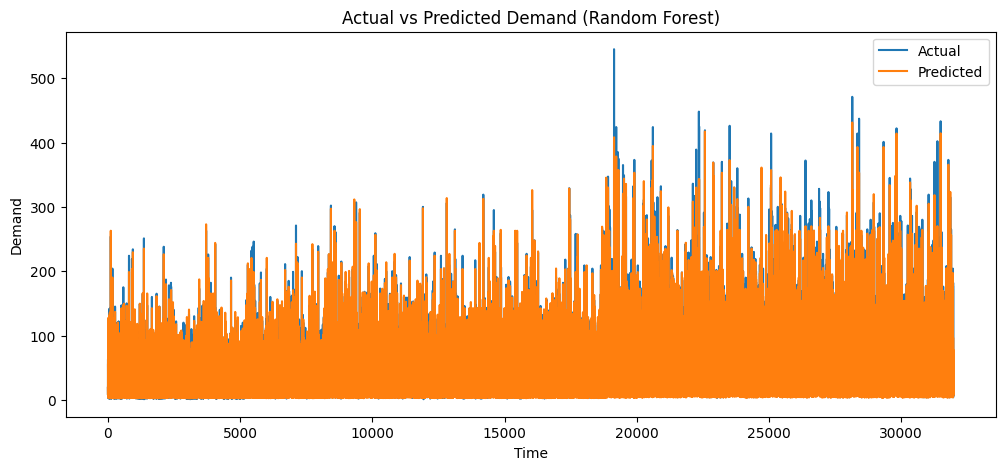

In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ---- Load and split (same logic as notebooks 05a/05b) ----
df = pd.read_csv("../data/processed/model_data.csv")
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").dropna().reset_index(drop=True)

split = int(len(df) * 0.8)
train = df.iloc[:split]
test = df.iloc[split:]

X_train = train.drop(columns=["Sales", "Date"])
y_train = train["Sales"]
X_test = test.drop(columns=["Sales", "Date"])
y_test = test["Sales"]

cat_cols = ["Product_ID", "Product", "Category", "Store", "City"]
preprocessor = ColumnTransformer(
    [("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)],
    remainder="passthrough"
)

# ---- Train both candidates ----
lr_model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])
lr_model.fit(X_train, y_train)

rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("rf", RandomForestRegressor(
        n_estimators=10, max_depth=8, random_state=42, n_jobs=-1
    ))
])
rf_model.fit(X_train, y_train)

# ---- Evaluate both on the held-out test set ----
def evaluate(name, model):
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    print(f"{name}")
    print(f"  MAE : {mae:.3f}")
    print(f"  RMSE: {rmse:.3f}")
    print(f"  R2  : {r2:.3f}\n")
    return {"model": model, "name": name, "mae": mae, "rmse": rmse, "r2": r2, "y_pred": y_pred}

results = [
    evaluate("Linear Regression", lr_model),
    evaluate("Random Forest", rf_model),
]

# ---- Pick the winner by R2 (higher is better) ----
best = max(results, key=lambda r: r["r2"])
print(f"Best model: {best['name']} (R2 = {best['r2']:.3f})")

# ---- Save the winner under the exact name app/forecasting.py expects ----
joblib.dump(best["model"], "../models/demand_forecasting_model.pkl")
print("Saved as ../models/demand_forecasting_model.pkl")

# ---- Plot the winning model's fit ----
plt.figure(figsize=(12, 5))
plt.plot(y_test.values, label="Actual")
plt.plot(best["y_pred"], label="Predicted")
plt.title(f"Actual vs Predicted Demand ({best['name']})")
plt.xlabel("Time")
plt.ylabel("Demand")
plt.legend()
plt.show()